## Exercise: Ensemble methods

#### In this train, we'll implement various ensemble methods using the Python scikit-learn library to enhance prediction models

### Learning Objectives
#### By the end of this train, you should be able to:
##### - Identify and apply different ensemble techniques within the scikit-learn framework.
##### - Execute an ensemble method to improve the performance of a predictive model on a given dataset.
##### - Evaluate and compare the effectiveness of ensemble methods versus single-model approaches.

## Exercise

### Exercise 1: Exploratory Data Analysis (EDA)

#### Before we dive into ensemble methods, it's crucial to start with a robust feature selection process. This will help ensure that our models are only trained on variables that have a significant impact on our predictive variable, `BiodiversityHealthIndex`.

#### Conduct a thorough EDA to understand the relationships between `BiodiversityHealthIndex` and other environmental indicators in the dataset. Look for patterns, anomalies,or any insights that can inform your feature selection process.

#### Steps:
##### 1. Load and inspect the dataset (URL: `https://raw.githubusercontent.com/Explore-AI/Public-Data/master/SDG_15_Life_on_Land_Dataset.csv`)
##### 2. Generate summary statistics for numerical features.
##### 3. Visualise the distribution of the `BiodiversityHealthIndex`
##### 4. Use a pairplot to visualise the relationships between variables

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/SDG_15_Life_on_Land_Dataset.csv')
df.head()

,Year,WaterQualityIndex,ClimateChangeImpactScore,LandUseChange,InvasiveSpeciesCount,ConservationFunding,EcoTourismImpact,ForestCoverChange,SoilQualityIndex,WaterUsage,RenewableEnergyUsage,CarbonEmissionLevels,AgriculturalIntensity,HabitatConnectivity,SpeciesReintroductionEfforts,PollinatorDiversity,BiodiversityHealthIndex
0,2010,35,7.542535,6.630073,39,46,1.193810,0.032204,70,33,13,22,1.419332,1.671324,9.311312,0.270434,0.194332
1,2010,13,1.617642,6.477132,45,18,8.484718,-4.803485,69,67,57,63,3.048794,5.815305,4.698086,0.729916,0.525779
2,2010,10,0.904817,9.069428,28,59,3.412444,-2.563852,72,85,37,46,7.863218,9.543694,2.080495,0.068508,0.684795
3,2010,36,7.060190,7.061932,37,88,9.718453,3.425382,64,85,96,60,1.065595,4.938359,2.192657,0.145065,0.926146
4,2010,24,8.439246,4.504786,41,88,9.118186,-1.295086,12,0,85,61,9.785784,2.114002,7.405189,0.809798,0.126345


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,1000.0,2014.840000,3.158540,2010.000000,2012.000000,2015.000000,2018.000000,2020.000000
WaterQualityIndex,1000.0,49.922000,29.283604,0.000000,25.000000,49.000000,75.000000,100.000000
ClimateChangeImpactScore,1000.0,4.928142,2.855896,0.001884,2.383995,4.957500,7.397943,9.970782
LandUseChange,1000.0,5.113608,2.847654,0.004428,2.708338,5.224919,7.586436,9.997138
InvasiveSpeciesCount,1000.0,25.018000,14.461979,0.000000,13.000000,24.000000,38.000000,50.000000
ConservationFunding,1000.0,49.741000,28.918129,0.000000,24.000000,49.000000,76.000000,100.000000
EcoTourismImpact,1000.0,4.940977,2.890359,0.002270,2.487451,4.762296,7.423117,9.987929
ForestCoverChange,1000.0,-0.019767,2.901123,-4.960816,-2.566369,0.012879,2.538136,4.994607
SoilQualityIndex,1000.0,50.089000,28.878834,0.000000,24.000000,51.000000,75.000000,100.000000
WaterUsage,1000.0,51.456000,28.799852,0.000000,28.000000,53.000000,76.000000,100.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          1000 non-null   int64  
 1   WaterQualityIndex             1000 non-null   int64  
 2   ClimateChangeImpactScore      1000 non-null   float64
 3   LandUseChange                 1000 non-null   float64
 4   InvasiveSpeciesCount          1000 non-null   int64  
 5   ConservationFunding           1000 non-null   int64  
 6   EcoTourismImpact              1000 non-null   float64
 7   ForestCoverChange             1000 non-null   float64
 8   SoilQualityIndex              1000 non-null   int64  
 9   WaterUsage                    1000 non-null   int64  
 10  RenewableEnergyUsage          1000 non-null   int64  
 11  CarbonEmissionLevels          1000 non-null   int64  
 12  AgriculturalIntensity         1000 non-null   float64
 13  Habi

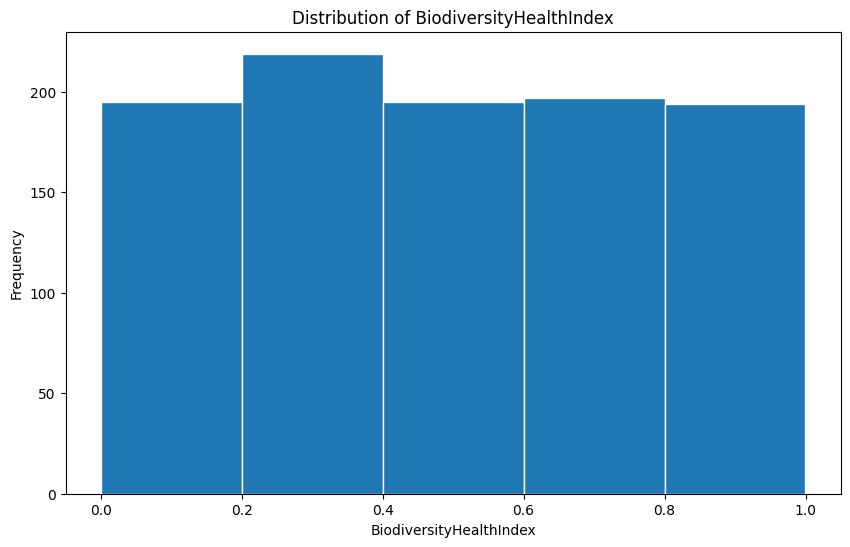

In [15]:
plt.figure(figsize=(10,6))

plt.hist(df['BiodiversityHealthIndex'], bins=5, edgecolor='white')
plt.xlabel('BiodiversityHealthIndex')
plt.ylabel('Frequency')
plt.title('Distribution of BiodiversityHealthIndex')

plt.show()

Text(0.5, 1.0, 'Density Plot for BiodiversityHealthIndex')

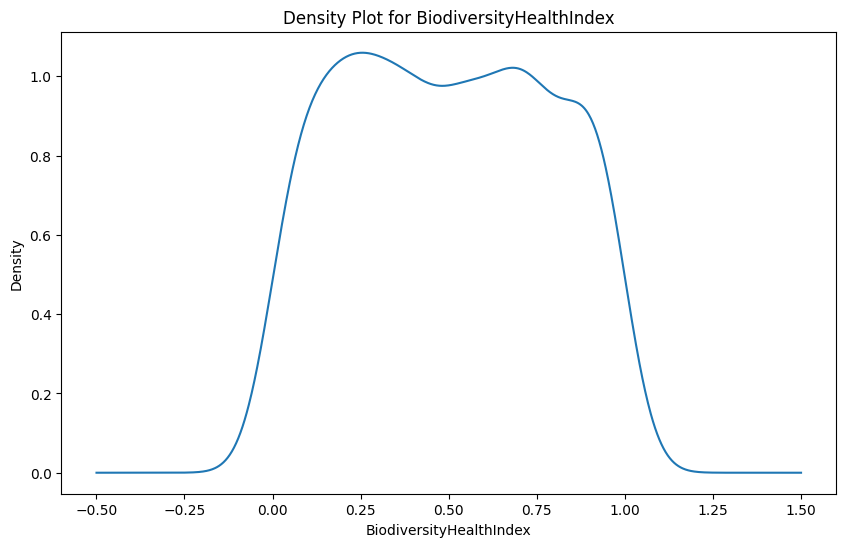

In [16]:
plt.figure(figsize=(10,6))

df['BiodiversityHealthIndex'].plot(kind='density')

plt.xlabel('BiodiversityHealthIndex')
plt.title('Density Plot for BiodiversityHealthIndex')

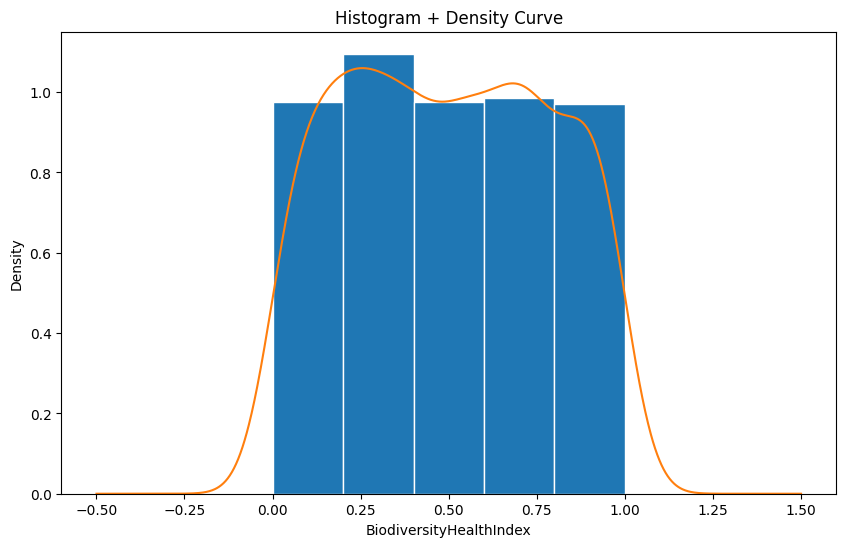

In [22]:
plt.figure(figsize=(10,6))

df['BiodiversityHealthIndex'].hist(bins=5, density=True, edgecolor='white')
df['BiodiversityHealthIndex'].plot(kind='density')

plt.xlabel('BiodiversityHealthIndex')
plt.title('Histogram + Density Curve')

plt.show()

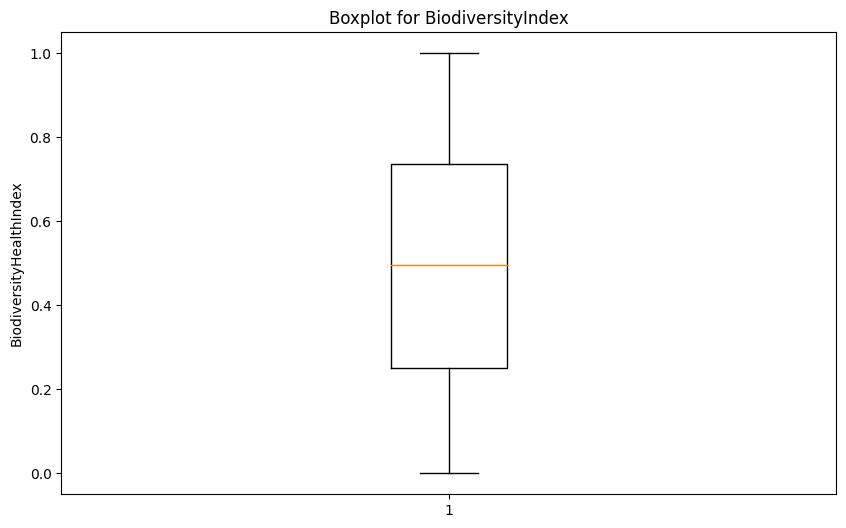

In [23]:
plt.figure(figsize=(10,6))

plt.boxplot(df['BiodiversityHealthIndex'])

plt.ylabel('BiodiversityHealthIndex')
plt.title('Boxplot for BiodiversityIndex')

plt.show()

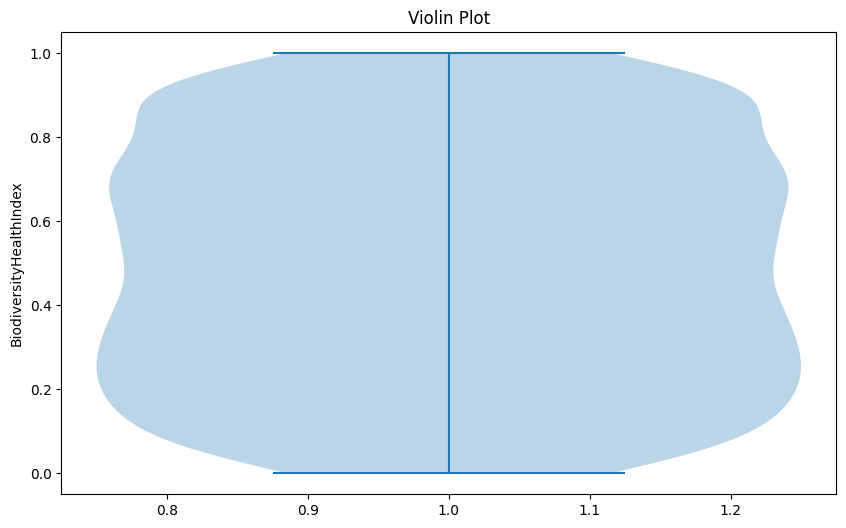

In [25]:
plt.figure(figsize=(10,6))

plt.violinplot(df['BiodiversityHealthIndex'])

plt.ylabel('BiodiversityHealthIndex')
plt.title('Violin Plot')

plt.show()

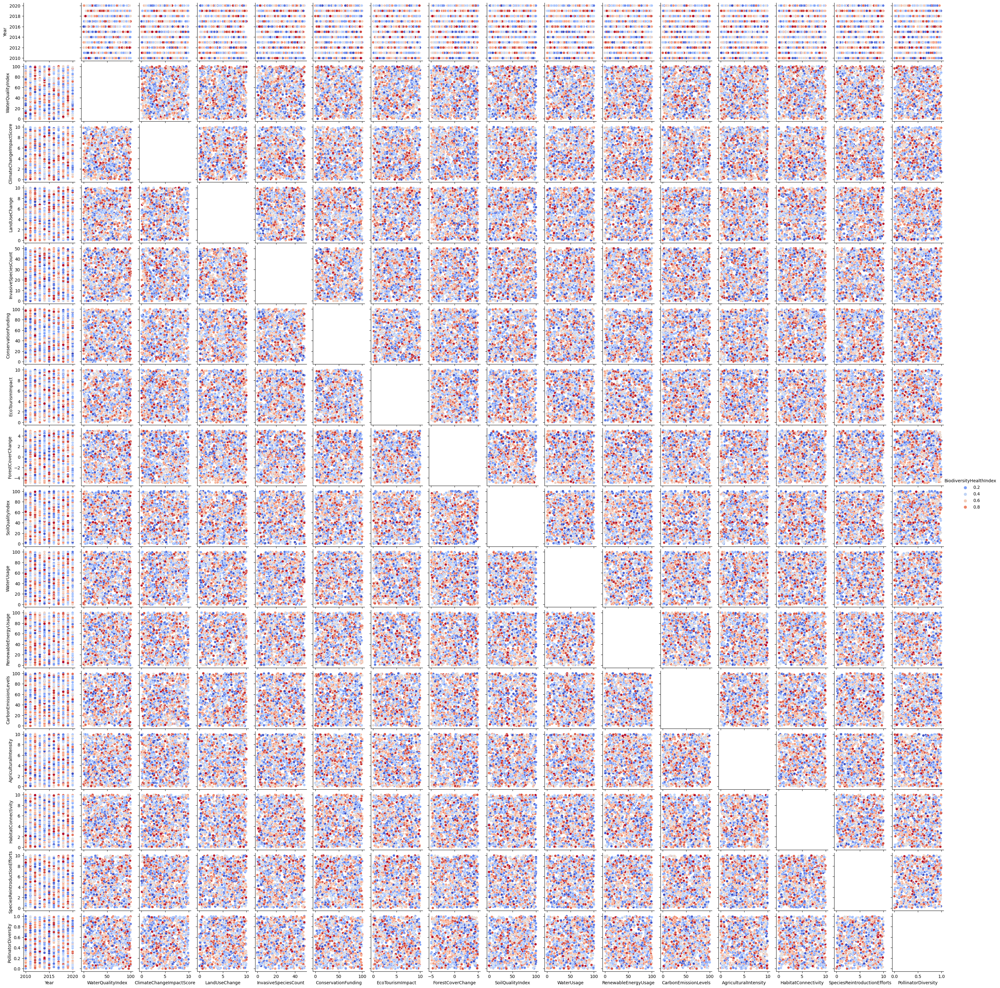

In [53]:
g = sns.pairplot(df, hue='BiodiversityHealthIndex', palette='coolwarm')

g.fig.set_size_inches(32, 32)

### Exercise 2: Correlation Analysis

#### Calculate the correlation coefficients between `BiodiversityHealthIndex` and each of the other environmental indicators. This will help us identify the variables most closely related to our target variable

In [33]:
corr = df.corr()['BiodiversityHealthIndex']

In [36]:
corr

Year                           -0.026502
WaterQualityIndex               0.023446
ClimateChangeImpactScore       -0.014917
LandUseChange                   0.040171
InvasiveSpeciesCount            0.031199
ConservationFunding            -0.042731
EcoTourismImpact               -0.066228
ForestCoverChange              -0.046136
SoilQualityIndex                0.023898
WaterUsage                      0.007323
RenewableEnergyUsage           -0.010840
CarbonEmissionLevels           -0.034371
AgriculturalIntensity           0.023563
HabitatConnectivity             0.008568
SpeciesReintroductionEfforts    0.047989
PollinatorDiversity             0.002505
BiodiversityHealthIndex         1.000000
Name: BiodiversityHealthIndex, dtype: float64

### Exercise 3: Selecting top variables and adjusting the dataset

#### Based on the correlation analysis, select the top six variables (`top_variables`) that show the highest correlation with `BiodiversityHealthIndex`. Adjust our dataset to include only the selected six variables and `BiodiversityHealthIndex`. This refined dataset will be used for training and testing our ensemble models.

In [42]:
top_variables = corr.loc[corr.abs().nlargest(6).index]

In [45]:
top_variables

BiodiversityHealthIndex         1.000000
EcoTourismImpact               -0.066228
SpeciesReintroductionEfforts    0.047989
ForestCoverChange              -0.046136
ConservationFunding            -0.042731
LandUseChange                   0.040171
Name: BiodiversityHealthIndex, dtype: float64

In [50]:
features = top_variables.index

featured_df = df[features]

In [51]:
featured_df

,BiodiversityHealthIndex,EcoTourismImpact,SpeciesReintroductionEfforts,ForestCoverChange,ConservationFunding,LandUseChange
0,0.194332,1.193810,9.311312,0.032204,46,6.630073
1,0.525779,8.484718,4.698086,-4.803485,18,6.477132
2,0.684795,3.412444,2.080495,-2.563852,59,9.069428
3,0.926146,9.718453,2.192657,3.425382,88,7.061932
4,0.126345,9.118186,7.405189,-1.295086,88,4.504786
...,...,...,...,...,...,...
995,0.355316,5.592181,3.828652,-1.240288,89,4.156039
996,0.179313,8.082682,8.829755,0.180153,43,1.878429
997,0.221916,4.856343,8.359844,4.994607,89,0.577029
998,0.608384,2.416589,0.283244,1.860912,82,8.058445


### Exercise 4: RandomForestRegressor

#### Implement a `RandomForestRegressor` from `scikit.ensemble` to predict `BiodiversityHealthIndex` based on other environmental indicators. Split the data into training and test sets., fit the `RandomForestRegressor` model on the training data, and calculate R-squared value on the test set

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [55]:
X = featured_df.drop('BiodiversityHealthIndex', axis=1)
y = featured_df['BiodiversityHealthIndex']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [57]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [59]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [60]:
y_pred = rf.predict(X_test)

In [62]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [64]:
print('MSE: ', mse)
print('R² :', r2)

MSE:  0.09416109608138366
R² : -0.15743511779480301


### Exercise 5: GradientBoostingRegressor

#### Introduce `GradientBoostingRegressor` to predict `BiodiversityHealthIndex` using the same dataset. Train the model on the same training data and evaluate its R² value on the test set. Compare its performance with the `RandomForestRegressor`

In [65]:
from sklearn.ensemble import GradientBoostingRegressor

In [67]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [69]:
gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [70]:
y_pred_gbr = gbr.predict(X_test)

In [71]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [72]:
print("MSE: ", mse)
print("R²: ", r2)

MSE:  0.09416109608138366
R²:  -0.15743511779480301
